## 1. Импорты

In [1]:
import os
import gc
import sys
import json
import toml
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import matplotlib.pyplot as plt
import tqdm
from prefect.blocks.system import Secret
from prefect.variables import Variable
import plotly.io as pio
from scipy.stats import linregress

import lightgbm as lgb
from sklearn.metrics import roc_auc_score

pio.renderers.default = "plotly_mimetype"

In [2]:
!pip install hyperopt

Looking in indexes: https://nexus/repository/pypi-proxy/simple


In [3]:
import lightgbm as lgb
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_squared_error, mean_absolute_error
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

## 2. Параметры

In [4]:
secret_cdw = await Secret.load("pass-sb-analytics")
secret_space = await Secret.load("pass-space")
secret_sb_dirkaim = await Secret.load("pass-sb-dirkaim")

In [5]:
SUBTASK = 'v5'             # Подзадача (или версия, свободное наименование)
COMMENT = ""               # Текст-подсказка в свободной форме, пояснение для разработчика
SEED = 41                  # random_state

USERNAME_SPACE = "analytics"
USERNAME_CDW = "sb_analytics"
USERNAME_SB_DIRKAIM = "kovalenkovdy"
PASSWORD_SPACE = secret_space.get()
PASSWORD_CDW = secret_cdw.get()
PASSWORD_SB_DIRKAIM = secret_sb_dirkaim.get()


common_params = toml.load('common_params.toml')

AUTHOR = common_params['AUTHOR']        # Разработчик
PREFIX = common_params['PREFIX']        # Префикс
TASK_NUM = common_params['TASK_NUM']    # Номер задачи eservices
OUT_TABLE = common_params['OUT_TABLE']  # out_table
ML_TYPE = common_params['ML_TYPE']      # Тип ML-задачи: reg - регрессия, clf - классификация clf, mclf - мультирег,mclf - мультикласс
TARGET = common_params['TARGET']        # Имя целевой переменной
TIME_COL = common_params['TIME_COL']    # Имя колонки с датами

PRIMARY_KEY = ['client_did', TIME_COL]      # Объект предсказания, ключ

# Технические поля - не фичи, не id, не дата, для удаления
TECH_COLS = [
    'ub_clients_registration_dt_diff_report_date',
    'ub_clients_client_email',
    'ub_clients_mailing_consent',
    "card_report_date_diff_card_work_dt_aggmin", # ЛИК в фиче! 18.12.2025
    'transaction_total_trans_cnt_1m',
    'transaction_ratio_cnt_trans_1m_to_1m',
    'transaction_supermarkets_trans_cnt_12m'
]


# Пути (для чтения файлов)
PATH_TO_UTILS = common_params['PATH_TO_UTILS'] # Путь к кастомной библиотеке toolbox

# Пути (для сохранения файлов)
DATA_FOLDER = common_params['DATA_FOLDER']            # Папка с выборками
MODELS_FOLDER = common_params['MODELS_FOLDER']        # Файлы модели
FEATURES_FOLDER = common_params['FEATURES_FOLDER']    # Папка с фичами
REPORTS_FOLDER = f'{MODELS_FOLDER}/{SUBTASK}/report'  # Папка с отчетами

# Пути к файлам
PATH_TO_SAMPLE = f'./{DATA_FOLDER}/sample.parquet'    # Исходная выборка для разработки
PATH_MODELS_DATA = f"./{MODELS_FOLDER}/{SUBTASK}"     # Папка с файлми модели

# Артефакты классификатора (из 02_template_clf_v4.ipynb)
CLF_SUBTASK = 'v4'
PATH_CLF_DATA = f"./{MODELS_FOLDER}/{CLF_SUBTASK}"
TARGET_CLF = 'target_clf'
CLF_SCORE_COL = 'clf_score'
ZERO_EPS = 1e-9

In [6]:
print(PATH_TO_SAMPLE, FEATURES_FOLDER, MODELS_FOLDER)
print(PATH_MODELS_DATA)
print(REPORTS_FOLDER)

./data/sample.parquet features_data models_data
./models_data/v5
models_data/v5/report


In [7]:
# Создаем необходимые директории
os.makedirs(MODELS_FOLDER, exist_ok=True)
os.makedirs(PATH_MODELS_DATA, exist_ok=True)
os.makedirs(REPORTS_FOLDER, exist_ok=True)

### Загрузка кастомного модуля

In [8]:
sys.path.append(PATH_TO_UTILS)

In [9]:
!pip install openpyxl # для from toolbox.modeling_utils.report

Looking in indexes: https://nexus/repository/pypi-proxy/simple


In [10]:
from toolbox.modeling_utils import preprocessing 
from toolbox.modeling_utils import report
from toolbox.modeling_utils import feature_selection
from toolbox.modeling_utils import report_generator
from toolbox import oracle

## 3. Логгирование

In [11]:
# Логгирование
import logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)s %(message)s",
    datefmt = "%Y-%m-%d %H:%M",
    handlers = [
        # logging.FileHandler("logfile.log"),
        logging.StreamHandler(),
    ])

In [12]:
!pip install clearml

Looking in indexes: https://nexus/repository/pypi-proxy/simple


In [13]:
os.environ["CLEARML_AUTO_LOG_ARTIFACTS"] = "0" 
os.environ["CLEARML_MONITOR_SYSTEM"]    = "0"
os.environ["CLEARML_AUTO_CONNECT_FRAMEWORKS"] = "0"

import clearml
from clearml import Task, Logger, Model

PROJECT_NAME = f"eservices-{TASK_NUM}"

clearml_task = Task.init(
    project_name=PROJECT_NAME,
    task_name=f"{PROJECT_NAME}_{SUBTASK}",
    auto_connect_streams=False,
    reuse_last_task_id=False
)

ClearML Task: created new task id=a751bf0ab0c246cf9313595427bb916d
ClearML results page: https://clearml-retail.run.fc.uralsibbank.ru/projects/12abac3b5607421e96058d1207fbf5cb/experiments/a751bf0ab0c246cf9313595427bb916d/output/log
2026-06-02 09:37:04,266 - clearml.Task - INFO - Storing jupyter notebook directly as code
2026-06-02 09:37:04,560 - clearml.resource_monitor - WARNING - Could not fetch GPU stats: NVML Shared Library Not Found
ClearML Monitor: GPU monitoring failed getting GPU reading, switching off GPU monitoring
ClearML Monitor: Could not detect iteration reporting, falling back to iterations as seconds-from-start


## 4 Чтение данных

В этом ноутбуке не собираем фичи заново. Берём train/test/oot из feature-universe артефактов классификатора (`sample_*_feature_universe.parquet`), то есть из полного набора признаков после missing/constant/PSI и до финального отбора фичей классификатора. `clf_score` и `target_clf` подтягиваем из `scored_df.parquet`, а непрерывный `target` — из исходного `sample.parquet`.


In [14]:
# Пути к артефактам классификатора
print('PATH_TO_SAMPLE:', PATH_TO_SAMPLE)
print('PATH_CLF_DATA:', PATH_CLF_DATA)
print('PATH_MODELS_DATA:', PATH_MODELS_DATA)

PATH_TO_SAMPLE: ./data/sample.parquet
PATH_CLF_DATA: ./models_data/v4
PATH_MODELS_DATA: ./models_data/v5


In [15]:
# Исходная выборка нужна для EDA и непрерывного target
sample = pd.read_parquet(PATH_TO_SAMPLE)
sample[TARGET] = pd.to_numeric(sample[TARGET], errors='coerce')

# Feature universe из классификатора: признаки после общих фильтров качества, но до финального отбора clf.
train_clf = pd.read_parquet(f'{PATH_CLF_DATA}/sample_train_feature_universe.parquet')
test_clf = pd.read_parquet(f'{PATH_CLF_DATA}/sample_test_feature_universe.parquet')
oot_clf = pd.read_parquet(f'{PATH_CLF_DATA}/sample_oot_feature_universe.parquet')
feature_universe = pd.read_csv(f'{PATH_CLF_DATA}/feature_universe_after_psi.csv')['feature'].tolist()

# Scored-файл нужен только для score классификатора и target_clf.
scored_clf = pd.read_parquet(f'{PATH_CLF_DATA}/scored_df.parquet')

display(sample.shape)
display(sample.head(3))
missing_feature_cols = [c for c in feature_universe if c not in train_clf.columns]
extra_feature_cols = [
    c for c in train_clf.columns
    if c not in PRIMARY_KEY + ['year_month'] + feature_universe
]

display({
    'train_feature_universe': train_clf.shape,
    'test_feature_universe': test_clf.shape,
    'oot_feature_universe': oot_clf.shape,
    'feature_universe_n': len(feature_universe),
    'feature_cols_missing_in_train': len(missing_feature_cols),
    'extra_non_feature_cols_in_train': extra_feature_cols,
    'scored_clf': scored_clf.shape,
})

if missing_feature_cols:
    display(pd.Series(missing_feature_cols, name='missing_feature_cols').head(50))

(270200, 5)

,client_did,report_date,current_debt_amt,new_limit,target
0,20127190033,2024-05-23,0.00,800000,0.000000
1,20117845254,2023-12-21,7955.77,90000,0.088397
2,1171690331,2024-04-25,9254.71,180000,0.051415


{'train_feature_universe': (198144, 786),
 'test_feature_universe': (49805, 786),
 'oot_feature_universe': (22161, 786),
 'feature_universe_n': 783,
 'feature_cols_missing_in_train': 0,
 'extra_non_feature_cols_in_train': [],
 'scored_clf': (270110, 5)}

## 4. EDA helpers

Здесь оставляем только функции и опциональные sanity-check блоки. Основная EDA для регрессии строится ниже, после выбора `best_threshold`, на популяции `train_reg/test_reg/oot_reg`.

In [16]:
# Динамика таргета во времени
sample['year_month'] = sample[TIME_COL].dt.strftime('%Y-%m-01')
sample['year_month'] = pd.to_datetime(sample['year_month'])

In [17]:
import plotly.express as px
import plotly.graph_objects as go

### Таргет по месяцам (аналог уровня таргета в классификации)
Среднее и медиана целевой переменной по месяцам — видно тренд и сезонность.

In [18]:
def target_by_month(df, date_col, target_cols, agg="mean", figsize=(12, 4), show=True):
    """График агрегата таргета по месяцам (agg: 'mean' или 'median')."""
    if isinstance(target_cols, str):
        target_cols = [target_cols]

    df = df.copy()
    df["_month"] = df[date_col].dt.to_period("M")
    g = df.groupby("_month", observed=True)[target_cols].agg(agg)

    plot_df = g.reset_index()
    plot_df["_month"] = plot_df["_month"].astype(str)

    fig = px.line(
        plot_df,
        x="_month",
        y=target_cols,
        title=f"Таргет по месяцам ({agg})",
        markers=True,
    )

    fig.update_layout(
        width=int(figsize[0] * 80),
        height=int(figsize[1] * 80),
        yaxis_title=agg,
        legend=dict(
            yanchor="top",
            y=1,
            xanchor="left",
            x=1.02,
        ),
        margin=dict(r=120),
    )
    fig.update_xaxes(tickangle=45)

    if show:
        fig.show()

    return g, fig

### Распределение таргета
Гистограмма и ящик с усами — асимметрия, выбросы, нули.

In [19]:
from plotly.subplots import make_subplots

In [20]:
def _target_grid(n, ncols):
    nrows = (n + ncols - 1) // ncols
    return nrows, ncols


def _default_figsize(ncols_plot, nrows, aspect=1.2):
    return (4 * ncols_plot, max(4, 3 * nrows * aspect))


def target_histogram(
    df,
    target_cols,
    ncols=2,
    log_scale=False,
    bins=30,
    figsize=None,
    show=True,
):
    """Гистограммы по списку таргетов (отдельная фигура для ClearML)."""
    if isinstance(target_cols, str):
        target_cols = [target_cols]

    n = len(target_cols)
    nrows, ncols_grid = _target_grid(n, ncols)

    if figsize is None:
        figsize = _default_figsize(ncols, nrows)

    fig = make_subplots(
        rows=nrows,
        cols=ncols_grid,
        subplot_titles=list(target_cols),
        horizontal_spacing=0.1,
        vertical_spacing=0.15 if nrows > 1 else 0.12,
    )

    for i, col in enumerate(target_cols):
        r = i // ncols + 1
        c = i % ncols + 1

        x = df[col].dropna().astype(float)
        x_hist = np.log1p(x) if log_scale and x.max() > 0 else x

        counts, edges = np.histogram(x_hist, bins=bins)
        centers = (edges[:-1] + edges[1:]) / 2
        widths = np.diff(edges)

        fig.add_trace(
            go.Bar(
                x=centers,
                y=counts,
                width=widths,
                marker=dict(line=dict(color="black", width=0.5)),
                opacity=0.7,
                showlegend=False,
                name=col,
                hovertemplate="значение: %{x:.4g}<br>число: %{y}<extra></extra>",
            ),
            row=r,
            col=c,
        )

    fig.update_layout(
        width=int(figsize[0] * 80),
        height=int(figsize[1] * 80),
        autosize=False,
        title_text="Гистограмма таргетов",
        margin=dict(l=50, r=30, t=70, b=50),
        bargap=0,
    )

    if show:
        fig.show()
    return fig

In [21]:
def target_boxplot(
    df,
    target_cols,
    ncols=2,
    figsize=None,
    show=True,
):
    if isinstance(target_cols, str):
        target_cols = [target_cols]
    n = len(target_cols)
    nrows, ncols_grid = _target_grid(n, ncols)
    if figsize is None:
        figsize = (3 * ncols_grid, max(3.5, 3 * nrows))
    fig, axes = plt.subplots(nrows, ncols_grid, figsize=figsize, squeeze=False)
    for i, col in enumerate(target_cols):
        r, c = i // ncols, i % ncols
        x = df[col].dropna().astype(float)
        axes[r, c].boxplot(x, vert=False)
        axes[r, c].set_title(f"{col} (box)")
        axes[r, c].set_xlabel(col)
    for j in range(n, nrows * ncols_grid):
        axes.flat[j].set_visible(False)
    fig.suptitle("Boxplot таргет", y=1.02)
    plt.tight_layout()
    if show:
        plt.show()
    return fig

### Сводка по таргетам: среднее, медиана, std, доля нулей
Таблица — общая и при необходимости по месяцам.

In [22]:
def target_summary(df, target_cols, by_month=False, date_col=None):
    """Таблица: count, mean, median, std, min, max, доля нулей. by_month=True — то же по месяцам."""
    df = df.copy()
    df[target_cols] = df[target_cols].astype(float)
    if by_month and date_col:   
        df["_month"] = df[date_col].dt.to_period("M")
        return df.groupby("_month")[target_cols].agg(
            ["count", "mean", "median", "std", "min", "max"]
        ).round(2)
    res = df[target_cols].agg(["count", "mean", "median", "std", "min", "max"]).T
    res["pct_zero"] = (df[target_cols] == 0).mean() * 100
    return res.round(2)

## 5. Готовим данные для регрессии после классификатора

Тяжёлые этапы из исходного шаблона (merge фичей, missing, constant, PSI, split) здесь пропущены: берём feature universe, сохранённый в классификаторе после общих фильтров качества. Добавляем непрерывный `target`, `target_clf` и `clf_score`.


In [23]:
target_df = sample[PRIMARY_KEY + [TARGET]].copy()
score_cols = PRIMARY_KEY + [TARGET_CLF, CLF_SCORE_COL, 'segment']
score_df = scored_clf.rename(columns={'score': CLF_SCORE_COL})[score_cols].copy()


def attach_target_and_score(df, segment_name):
    out = df.copy()
    # На случай если старый feature-universe был сохранён вместе с target_clf, не дублируем колонку.
    out = out.drop(columns=[TARGET, TARGET_CLF, CLF_SCORE_COL, 'segment'], errors='ignore')
    out = out.merge(target_df, on=PRIMARY_KEY, how='left', validate='one_to_one')
    segment_scores = score_df[score_df['segment'] == segment_name][PRIMARY_KEY + [TARGET_CLF, CLF_SCORE_COL]]
    out = out.merge(segment_scores, on=PRIMARY_KEY, how='left', validate='one_to_one')
    return out


train = attach_target_and_score(train_clf, 'train')
test = attach_target_and_score(test_clf, 'test')
oot = attach_target_and_score(oot_clf, 'oot')
merged_df = pd.concat([train, test, oot], ignore_index=True)

for name, df in [('train', train), ('test', test), ('oot', oot)]:
    print(
        name,
        df.shape,
        '| target nan:', df[TARGET].isna().sum(),
        '| target_clf nan:', df[TARGET_CLF].isna().sum(),
        '| score nan:', df[CLF_SCORE_COL].isna().sum(),
        '| y>0:', f'{(df[TARGET] > ZERO_EPS).mean():.1%}',
        '| feature_universe columns:', len([c for c in feature_universe if c in df.columns]),
    )


train (198144, 789) | target nan: 0 | target_clf nan: 0 | score nan: 0 | y>0: 64.4% | feature_universe columns: 783
test (49805, 789) | target nan: 0 | target_clf nan: 0 | score nan: 0 | y>0: 64.1% | feature_universe columns: 783
oot (22161, 789) | target nan: 0 | target_clf nan: 0 | score nan: 0 | y>0: 67.4% | feature_universe columns: 783


In [24]:
merged_df.info()
merged_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270110 entries, 0 to 270109
Columns: 789 entries, client_did to clf_score
dtypes: category(9), datetime64[ns](2), float16(392), float32(290), float64(29), int16(7), int32(18), int64(1), int8(41)
memory usage: 601.7 MB


(270110, 789)

In [25]:
display(merged_df.columns[:15])

Index(['client_did', 'report_date', 'year_month',
       'card_ozc_flg_by_status_card_nm_aggmax',
       'card_is_digital_by_status_card_nm_aggmax',
       'card_izp_flg_by_status_card_nm_aggmax',
       'card_sms_end_diff_sms_start_aggmin_d730',
       'card_sms_end_diff_sms_start_aggmin_d365',
       'card_sms_end_diff_sms_start_aggmin_d180',
       'card_sms_end_diff_sms_start_aggmin_d90',
       'card_sms_end_diff_sms_start_aggmax_d90',
       'card_bm_off_diff_bm_on_aggmin_d730',
       'card_bm_off_diff_bm_on_aggmin_d365',
       'card_bm_off_diff_bm_on_aggmin_d180',
       'card_bm_off_diff_bm_on_aggmin_d90'],
      dtype='object')

### Проверка

In [26]:
# Проверка уникальности ключей после merge
assert merged_df[PRIMARY_KEY].drop_duplicates().shape[0] == merged_df[PRIMARY_KEY].shape[0]

In [27]:
# Проверяем, что score и непрерывный target подтянулись
assert merged_df[TARGET].notna().all()
assert merged_df[CLF_SCORE_COL].notna().all()

In [28]:
display(merged_df.shape)
display(merged_df[[TARGET, TARGET_CLF, CLF_SCORE_COL]].describe())

(270110, 789)

,target,target_clf,clf_score
count,270110.000000,270110.000000,270110.000000
mean,0.404023,0.645829,0.645554
std,0.535149,0.478262,0.219952
min,0.000000,0.000000,0.023453
25%,0.000000,0.000000,0.530918
50%,0.125495,1.000000,0.692754
75%,0.854853,1.000000,0.817307
max,19.714000,1.000000,0.980206


## 6. Пропущенные этапы отбора

Пропускаем missing / constant / PSI, потому что используем уже сохранённые признаки классификатора. Это фиксирует train/test/oot и исключает риск, что регрессия будет обучена на другой популяции.


### 6.4 Разбиение на сегменты

Используем ровно те же train/test/oot, что и в классификаторе.


In [29]:
train.shape, test.shape, oot.shape

((198144, 789), (49805, 789), (22161, 789))

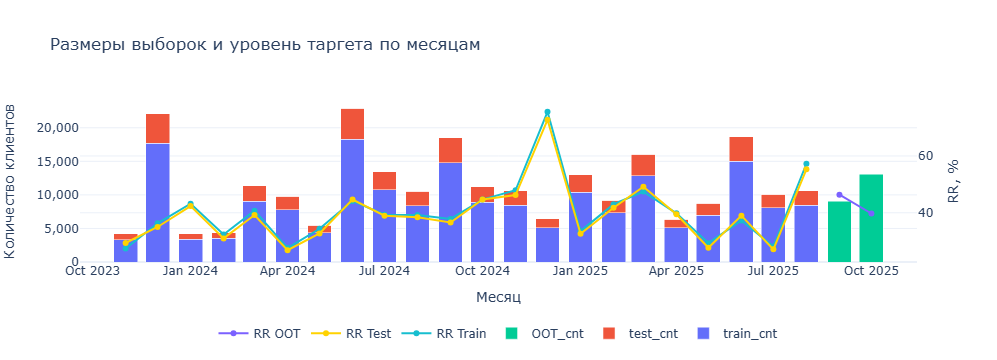

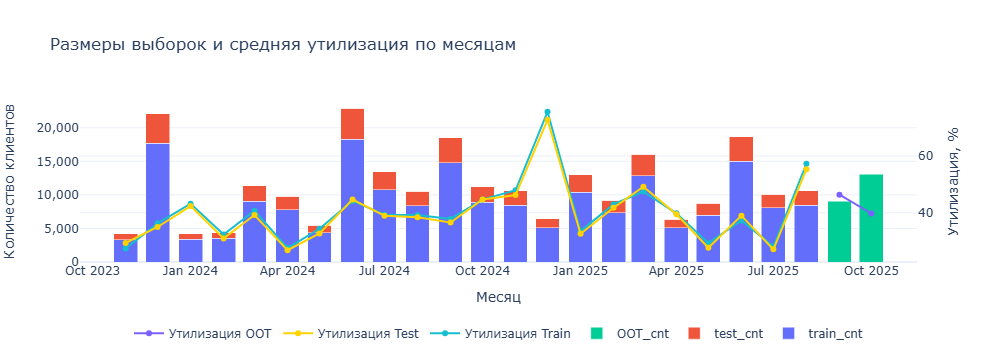

In [30]:
info_df, fig_df = report.counts_target_ratio(train, test, oot, TIME_COL, TARGET)
fig_df.update_layout(
    title="Размеры выборок и средняя утилизация по месяцам",
    yaxis2=dict(title="Утилизация, %", overlaying="y", side="right"),
)
for tr in fig_df.data:
    if tr.name and tr.name.startswith("RR "):
        tr.name = tr.name.replace("RR ", "Утилизация ")

info_df = info_df.rename(columns={
    "rr_train": "util_train",
    "rr_test": "util_test",
    "rr_oot": "util_oot",
})
fig_df

In [31]:
info_df

,month,train_cnt,test_cnt,oot_cnt,util_train,util_test,util_oot
0,2023-11-01,3344,885,---,27.44%,29.35%,---
1,2023-12-01,17688,4376,---,36.26%,34.99%,---
2,2024-01-01,3388,822,---,43.2%,42.34%,---
3,2024-02-01,3505,891,---,32.35%,30.96%,---
4,2024-03-01,9027,2304,---,40.74%,39.19%,---
5,2024-04-01,7808,1971,---,27.54%,26.83%,---
6,2024-05-01,4378,1092,---,34.36%,32.7%,---
7,2024-06-01,18293,4640,---,44.17%,44.67%,---
8,2024-07-01,10754,2676,---,39.31%,38.96%,---
9,2024-08-01,8372,2182,---,39.18%,38.42%,---


In [32]:
Logger.current_logger().report_plotly(
    title="Размеры выборок и средняя утилизация по месяцам",
    series="",
    figure=fig_df)

In [33]:
info_df_to_log = info_df.copy()
info_df_to_log["month"] = pd.to_datetime(info_df_to_log["month"]).dt.strftime("%Y-%m-%d")
Logger.current_logger().report_table(
    title="Размеры выборок и средняя утилизация по месяцам",
    series="",
    table_plot=info_df_to_log
)
info_df

,month,train_cnt,test_cnt,oot_cnt,util_train,util_test,util_oot
0,2023-11-01,3344,885,---,27.44%,29.35%,---
1,2023-12-01,17688,4376,---,36.26%,34.99%,---
2,2024-01-01,3388,822,---,43.2%,42.34%,---
3,2024-02-01,3505,891,---,32.35%,30.96%,---
4,2024-03-01,9027,2304,---,40.74%,39.19%,---
5,2024-04-01,7808,1971,---,27.54%,26.83%,---
6,2024-05-01,4378,1092,---,34.36%,32.7%,---
7,2024-06-01,18293,4640,---,44.17%,44.67%,---
8,2024-07-01,10754,2676,---,39.31%,38.96%,---
9,2024-08-01,8372,2182,---,39.18%,38.42%,---


In [34]:
# Проверка на потерянные строки
assert train[PRIMARY_KEY].shape[0] + test[PRIMARY_KEY].shape[0] + oot[PRIMARY_KEY].shape[0] == sample.dropna(subset=[TARGET]).shape[0]

## 7. Предварительный отбор фичей

In [35]:
NON_FEATURES = set(PRIMARY_KEY + [TIME_COL, 'year_month', TARGET, TARGET_CLF, CLF_SCORE_COL, 'segment'])

categorical_features = list(
    train.drop(columns=[c for c in NON_FEATURES if c in train.columns], errors='ignore')
         .select_dtypes(['category', 'object'])
         .columns
)
numerical_features = list(
    train.drop(columns=categorical_features + [c for c in NON_FEATURES if c in train.columns], errors='ignore')
         .select_dtypes(include=[np.number, 'bool'])
         .columns
)

print(f'Categorical: {len(categorical_features)}')
print(f'Numerical: {len(numerical_features)}')

Categorical: 9
Numerical: 774


In [36]:
features = categorical_features + numerical_features
print(f'Фичей до грубого отбора: {len(features)}')

Фичей до грубого отбора: 783


In [37]:
# LightGBM умеет работать с pandas category dtype.
# Выравниваем категории между train/test/oot, чтобы predict не ломался на разных наборах значений.
for col in categorical_features:
    categories = pd.concat(
        [train[col], test[col], oot[col]],
        ignore_index=True,
    ).dropna().unique()
    cat_dtype = pd.CategoricalDtype(categories=categories)
    train[col] = train[col].astype(cat_dtype)
    test[col] = test[col].astype(cat_dtype)
    oot[col] = oot[col].astype(cat_dtype)
    merged_df[col] = merged_df[col].astype(cat_dtype)

features

['client_cl_category_nm',
 'client_izp_flg',
 'client_call_consent_flg',
 'client_sms_consent_flg',
 'client_messenger_consent_flg',
 'client_email_consent_flg',
 'application_employer_ownership_type',
 'dbo_client_info_status_profile',
 'dbo_client_info_push_flg',
 'card_ozc_flg_by_status_card_nm_aggmax',
 'card_is_digital_by_status_card_nm_aggmax',
 'card_izp_flg_by_status_card_nm_aggmax',
 'card_sms_end_diff_sms_start_aggmin_d730',
 'card_sms_end_diff_sms_start_aggmin_d365',
 'card_sms_end_diff_sms_start_aggmin_d180',
 'card_sms_end_diff_sms_start_aggmin_d90',
 'card_sms_end_diff_sms_start_aggmax_d90',
 'card_bm_off_diff_bm_on_aggmin_d730',
 'card_bm_off_diff_bm_on_aggmin_d365',
 'card_bm_off_diff_bm_on_aggmin_d180',
 'card_bm_off_diff_bm_on_aggmin_d90',
 'card_bm_off_diff_bm_on_aggmax_d90',
 'card_spec_offer_code_aggmax_d90',
 'dbo_client_authorize_days_from_last_mb_success_auth',
 'dbo_client_authorize_web_aggsum_m6',
 'dbo_client_authorize_web_aggsum_m3',
 'dbo_client_authorize_w

In [38]:
def _lgbm_categorical(cols):
    """Категориальные признаки из текущего набора колонок для LightGBM."""
    return [c for c in cols if c in categorical_features]


def _fit_lgbm(model, X, y, eval_set=None):
    cat_cols = _lgbm_categorical(list(X.columns))
    fit_kwargs = {}
    if cat_cols:
        fit_kwargs["categorical_feature"] = cat_cols
    if eval_set is not None:
        fit_kwargs["eval_set"] = eval_set
    return model.fit(X, y, **fit_kwargs)


def select_by_importance(data, target_col, eval_data, max_features=None, importance_threshold=None, random_state=42):
    """
    Важность из LGBMRegressor. Возвращает (selected, imp, model) — model для evaluate_model.
    Категориальные признаки используются через pandas category dtype + categorical_feature.
    """
    X = data.drop(columns=[target_col]).copy()
    y = data[target_col]
    X_ev = eval_data.drop(columns=[target_col]).copy()
    y_ev = eval_data[target_col]

    m = lgb.LGBMRegressor(random_state=random_state, n_estimators=100, max_depth=4, verbosity=-1)
    _fit_lgbm(m, X, y, eval_set=[(X_ev[X.columns], y_ev)])
    imp = pd.Series(m.feature_importances_, index=X.columns).sort_values(ascending=False)
    selected = imp[imp >= importance_threshold].index.tolist() if importance_threshold is not None else imp.index.tolist()
    if max_features is not None:
        selected = imp.head(max_features).index.tolist()
    return selected, imp, m


def evaluate_model(model, train_df, test_df, oot_df, target_col):
    """
    Сводка по модели: Train / Test / OOT. Возвращает DataFrame с колонками:
    Target, AVG target, AVG pred, Dataset, MAPE, MAE, MAE 95%, RMSE, Non Zero.
    MAE 95% — MAE по 95% данных без 5% наибольших значений таргета y (выбросы по y).
    """
    feat = getattr(model, "feature_name_", None) or getattr(model, "feature_names_in_", None)
    if feat is None:
        feat = [c for c in train_df.columns if c != target_col]
    rows = []
    for name, df in [("Train", train_df), ("Test", test_df), ("OOT", oot_df)]:
        X = df[feat] if all(c in df.columns for c in feat) else df.drop(columns=[target_col])
        y = df[target_col].values
        pred = model.predict(X)
        nz = (y != 0)
        mape = np.mean(np.abs((y - pred)[nz]) / y[nz]) if nz.sum() > 0 else np.nan
        mae = np.mean(np.abs(y - pred))
        thresh_y = np.percentile(y, 95)
        mask = y <= thresh_y
        mae_95 = np.mean(np.abs(y[mask] - pred[mask])) if mask.sum() > 0 else np.nan
        rmse = np.sqrt(np.mean((y - pred) ** 2))
        rows.append({
            "Target": target_col,
            "AVG target": y.mean(),
            "AVG pred": pred.mean(),
            "Dataset": name,
            "MAPE": mape,
            "MAE": mae,
            "MAE 95%": mae_95,
            "RMSE": rmse,
            "Non Zero": int(nz.sum()),
        })
    return pd.DataFrame(rows)

In [39]:
def metric_vs_n_features(data, target_col, eval_data, imp, step=30, metric="rmse", random_state=42, threshold=0.005):
    """
    Перебор числа признаков по важности: от 20 с шагом step до n_all. imp — результат select_by_importance.
    threshold: порог — берётся наименьшее n, при котором метрика <= минимум * (1 + threshold). Например 0.005 = 0.5%.
    Если None — просто argmin. Возвращает (report_df, best_n, selected, model).
    """
    MIN_FEATURES = 20
    n_all = len(imp)
    start = min(MIN_FEATURES, n_all)
    n_features_list = list(range(start, n_all + 1, step))
    if n_all not in n_features_list:
        n_features_list.append(n_all)
    n_features_list = sorted(set(n_features_list))

    X_ev = eval_data[imp.index.tolist()].copy()
    y_ev = eval_data[target_col].values
    fn = mean_squared_error if metric == "rmse" else mean_absolute_error

    rows = []
    for n in n_features_list:
        cols = imp.head(n).index.tolist()
        X_tr = data[cols].copy()
        y_tr = data[target_col]
        m = lgb.LGBMRegressor(random_state=random_state, n_estimators=100, max_depth=4, verbosity=-1)
        _fit_lgbm(m, X_tr, y_tr, eval_set=[(X_ev[cols], y_ev)])
        pred = m.predict(X_ev[cols])
        val = np.sqrt(fn(y_ev, pred)) if metric == "rmse" else fn(y_ev, pred)
        rows.append({"n_features": n, "metric_value": val})

    report_df = pd.DataFrame(rows)
    best_metric = report_df["metric_value"].min()
    if threshold is not None:
        metric_limit = best_metric * (1 + threshold)
        candidates = report_df[report_df["metric_value"] <= metric_limit].sort_values("n_features")
        best_n = int(candidates.iloc[0]["n_features"]) if len(candidates) > 0 else int(report_df.loc[report_df["metric_value"].idxmin(), "n_features"])
    else:
        best_n = int(report_df.loc[report_df["metric_value"].idxmin(), "n_features"])
    selected = imp.head(best_n).index.tolist()
    model = lgb.LGBMRegressor(random_state=random_state, n_estimators=100, max_depth=4, verbosity=-1)
    _fit_lgbm(model, data[selected].copy(), data[target_col], eval_set=[(eval_data[selected].copy(), eval_data[target_col])])

    plt.figure(figsize=(8, 4))
    plt.plot(report_df["n_features"], report_df["metric_value"], marker="o")
    plt.axvline(best_n, color="gray", linestyle="--", label=f"best n={best_n}")
    plt.xlabel("Число признаков")
    plt.ylabel(metric.upper())
    plt.title(f"Метрика на eval от n для {target_col}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return report_df, best_n, selected, model

In [40]:
def tune_hyperparams(data, target_col, eval_data, max_evals=30, metric="rmse", random_state=42):
    """
    Подбор гиперпараметров LGBM через Hyperopt (TPE). 
    Возвращает (best_model, best_params).
    """
    X = data.drop(columns=[target_col]).copy()
    y = data[target_col]
    X_ev = eval_data.drop(columns=[target_col]).copy()
    y_ev = eval_data[target_col].values
    fn = mean_squared_error if metric == "rmse" else mean_absolute_error


    space = {
        "n_estimators": hp.quniform("n_estimators", 50, 300, 25),
        "max_depth": hp.quniform("max_depth", 3, 10, 1),
        "learning_rate": hp.loguniform("learning_rate", np.log(0.02), np.log(0.3)),
        "num_leaves": hp.quniform("num_leaves", 15, 127, 10),
        "min_child_samples": hp.quniform("min_child_samples", 5, 50, 5),
    }

    def objective(params):
        p = {
            "n_estimators": int(params["n_estimators"]),
            "max_depth": int(params["max_depth"]),
            "learning_rate": params["learning_rate"],
            "num_leaves": int(params["num_leaves"]),
            "min_child_samples": int(params["min_child_samples"]),
        }
        m = lgb.LGBMRegressor(random_state=random_state, verbosity=-1, **p)
        _fit_lgbm(m, X, y, eval_set=[(X_ev[X.columns], y_ev)])
        pred = m.predict(X_ev[X.columns])
        score = np.sqrt(fn(y_ev, pred)) if metric == "rmse" else fn(y_ev, pred)
        return {"loss": score, "status": STATUS_OK}

    trials = Trials()
    best = fmin(
        objective, space, algo=tpe.suggest, max_evals=max_evals, trials=trials,
        rstate=np.random.default_rng(random_state),
    )
    best_params = {
        "n_estimators": int(best["n_estimators"]),
        "max_depth": int(best["max_depth"]),
        "learning_rate": best["learning_rate"],
        "num_leaves": int(best["num_leaves"]),
        "min_child_samples": int(best["min_child_samples"]),
    }
    best_model = lgb.LGBMRegressor(random_state=random_state, verbosity=-1, **best_params)
    _fit_lgbm(best_model, X, y, eval_set=[(X_ev[X.columns], y_ev)])
    return best_model, best_params

,Dataset,clf_threshold,MAE_all,MAE_y_gt_0,MAE_y_eq_0,share_train_to_reg,share_pred_zero,share_true_zero,AVG target,AVG pred,train_reg_n
0,Test,0.00,0.329304,0.351594,0.289507,1.000000,0.023853,0.359020,0.398123,0.401209,198144
1,OOT,0.00,0.335787,0.332619,0.342346,1.000000,0.017508,0.325707,0.424555,0.440225,198144
2,Test,0.05,0.329097,0.351463,0.289165,0.997038,0.024917,0.359020,0.398123,0.401226,197557
3,OOT,0.05,0.335619,0.332589,0.341892,0.997038,0.018320,0.325707,0.424555,0.440048,197557
4,Test,0.10,0.328226,0.351296,0.287038,0.971733,0.039655,0.359020,0.398123,0.400462,192543
5,OOT,0.10,0.335295,0.332232,0.341637,0.971733,0.027481,0.325707,0.424555,0.440464,192543
6,Test,0.15,0.327212,0.351217,0.284353,0.950591,0.057303,0.359020,0.398123,0.399720,188354
7,OOT,0.15,0.334861,0.332843,0.339037,0.950591,0.043139,0.325707,0.424555,0.439406,188354
8,Test,0.20,0.326632,0.351450,0.282324,0.934109,0.071579,0.359020,0.398123,0.399170,185088
9,OOT,0.20,0.333777,0.332474,0.336475,0.934109,0.057534,0.325707,0.424555,0.439628,185088


Выбранный порог clf_score по Test MAE_all: 0.70
regression samples by clf threshold: (95774, 789) (23865, 789) (11712, 789)
true y>0 share inside regression samples: train=84.7% test=81.7% oot=82.1%


/opt/conda/lib/python3.11/site-packages/clearml/utilities/plotlympl/mplexporter/exporter.py:101: UserWarning:

Blended transforms not yet supported. Zoom behavior may not work as expected.



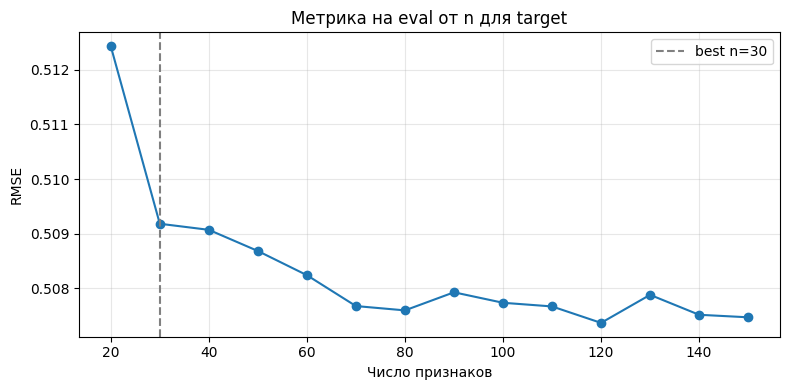

  0%|          | 0/30 [00:00<?, ?trial/s, best loss=?]

2026-06-02 09:49 INFO build_posterior_wrapper took 0.001060 seconds
2026-06-02 09:49 INFO TPE using 0 trials


  3%|▎         | 1/30 [00:01<00:37,  1.28s/trial, best loss: 0.5077706113884937]

2026-06-02 09:49 INFO build_posterior_wrapper took 0.001112 seconds
2026-06-02 09:49 INFO TPE using 1/1 trials with best loss 0.507771


  7%|▋         | 2/30 [00:03<00:55,  1.99s/trial, best loss: 0.5077706113884937]

...

 93%|█████████▎| 28/30 [00:27<00:02,  1.02s/trial, best loss: 0.5072612439545564]

2026-06-02 09:50 INFO build_posterior_wrapper took 0.001034 seconds
2026-06-02 09:50 INFO TPE using 28/28 trials with best loss 0.507261


 97%|█████████▋| 29/30 [00:28<00:01,  1.10s/trial, best loss: 0.5072612439545564]

2026-06-02 09:50 INFO build_posterior_wrapper took 0.001121 seconds
2026-06-02 09:50 INFO TPE using 29/29 trials with best loss 0.507261


100%|██████████| 30/30 [00:29<00:00,  1.02trial/s, best loss: 0.5072612439545564]
CPU times: user 32min 41s, sys: 27.4 s, total: 33min 8s
Wall time: 3min 29s


In [41]:
%%time
PRESELECTION_TOP_N = min(150, len(features))  # грубый отбор по importance оставляем

# Важно: регрессию нельзя обучать на target > 0 — нельзя использовать данные из будущего.
# В проде в регрессию попадут клиенты, которых пропустил классификатор.
# Поэтому сначала подбираем порог clf_score, каждый раз обучая регрессию на train[clf_score >= threshold].

def hurdle_predict(clf_score, reg_pred, threshold):
    reg_pred = np.clip(reg_pred, 0, None)
    return np.where(clf_score >= threshold, reg_pred, 0.0)


def score_hurdle(df, model, model_features, threshold, dataset_name):
    y_true = df[TARGET].astype(float).values
    reg_pred = model.predict(df[model_features])
    util_pred = hurdle_predict(df[CLF_SCORE_COL].astype(float).values, reg_pred, threshold)
    true_pos = y_true > ZERO_EPS

    return {
        'Dataset': dataset_name,
        'clf_threshold': threshold,
        'MAE_all': mean_absolute_error(y_true, util_pred),
        'MAE_y_gt_0': mean_absolute_error(y_true[true_pos], util_pred[true_pos]) if true_pos.any() else np.nan,
        'MAE_y_eq_0': mean_absolute_error(y_true[~true_pos], util_pred[~true_pos]) if (~true_pos).any() else np.nan,
        'share_train_to_reg': np.nan,
        'share_pred_zero': (util_pred <= ZERO_EPS).mean(),
        'share_true_zero': (~true_pos).mean(),
        'AVG target': y_true.mean(),
        'AVG pred': util_pred.mean(),
    }


threshold_grid = np.round(np.arange(0.00, 0.96, 0.05), 2)
threshold_rows = []

for threshold in threshold_grid:
    train_gate = train[train[CLF_SCORE_COL] >= threshold].copy()
    if len(train_gate) < 1000:
        continue

    quick_model = lgb.LGBMRegressor(
        random_state=SEED,
        n_estimators=150,
        max_depth=4,
        learning_rate=0.05,
        verbosity=-1,
    )
    _fit_lgbm(quick_model, train_gate[features].copy(), train_gate[TARGET])

    for dataset_name, df_eval in [('Test', test), ('OOT', oot)]:
        row = score_hurdle(df_eval, quick_model, features, threshold, dataset_name)
        row['share_train_to_reg'] = len(train_gate) / len(train)
        row['train_reg_n'] = len(train_gate)
        threshold_rows.append(row)

threshold_selection_report = pd.DataFrame(threshold_rows)
display(threshold_selection_report)

# Порог выбираем по Test, OOT оставляем как честную финальную проверку.
mae_test = threshold_selection_report[threshold_selection_report['Dataset'] == 'Test']
mae_oot = threshold_selection_report[threshold_selection_report['Dataset'] == 'OOT']
best_threshold = float(mae_test.loc[mae_test['MAE_all'].idxmin(), 'clf_threshold'])
print(f'Выбранный порог clf_score по Test MAE_all: {best_threshold:.2f}')

train_reg = train[train[CLF_SCORE_COL] >= best_threshold].copy()
test_reg = test[test[CLF_SCORE_COL] >= best_threshold].copy()
oot_reg = oot[oot[CLF_SCORE_COL] >= best_threshold].copy()

print('regression samples by clf threshold:', train_reg.shape, test_reg.shape, oot_reg.shape)
print('true y>0 share inside regression samples:',
      f"train={((train_reg[TARGET] > ZERO_EPS).mean()):.1%}",
      f"test={((test_reg[TARGET] > ZERO_EPS).mean()):.1%}",
      f"oot={((oot_reg[TARGET] > ZERO_EPS).mean()):.1%}")

results = {}

for target in [TARGET]:
    # 1) Грубый отбор по importance уже на train_reg, то есть на предсказанном class 1.
    selected, imp, _ = select_by_importance(
        train_reg[features + [target]],
        target,
        eval_data=test_reg[features + [target]],
        max_features=PRESELECTION_TOP_N,
        random_state=SEED,
    )

    # 2) Подбор числа фичей по качеству на test_reg.
    report_n, best_n, selected, model = metric_vs_n_features(
        train_reg[selected + [target]],
        target,
        eval_data=test_reg[selected + [target]],
        imp=imp[selected],
        step=10,
        threshold=0.01,
        random_state=SEED,
    )

    # 3) Подбор гиперпараметров на train_reg.
    best_model, best_params = tune_hyperparams(
        train_reg[selected + [target]],
        target,
        test_reg[selected + [target]],
        max_evals=30,
        random_state=SEED,
    )

    report_reg = evaluate_model(
        best_model,
        train_reg[selected + [target]],
        test_reg[selected + [target]],
        oot_reg[selected + [target]],
        target,
    )

    results[target] = {
        'selected': selected,
        'model': best_model,
        'evaluate_report': report_reg,
        'best_n': best_n,
        'best_params': best_params,
        'metric_vs_n': report_n,
        'importance': imp,
        'clf_threshold': best_threshold,
        'threshold_selection_report': threshold_selection_report,
    }

reports_all = pd.concat([results[t]['evaluate_report'] for t in [TARGET]], ignore_index=True)
best_features = results[TARGET]['selected']
best_model = results[TARGET]['model']

In [42]:
reports_all

,Target,AVG target,AVG pred,Dataset,MAPE,MAE,MAE 95%,RMSE,Non Zero
0,target,0.617500,0.617500,Train,273.059204,0.358897,0.325424,0.491606,81095
1,target,0.595240,0.615762,Test,605.479967,0.380880,0.348097,0.507261,19497
2,target,0.580855,0.649216,OOT,29.537795,0.365496,0.347604,0.451239,9619


In [43]:
from sklearn.metrics import r2_score

In [44]:
def check_working_model(train, train_pred):
    y = train["target"].astype(float).values
    y_const = np.full_like(y, y.mean())
    print("MAE const:", mean_absolute_error(y, y_const))
    print("R2 model :", r2_score(y, train_pred))

In [45]:
# Проверка качества регрессии на тех, кого классификатор пропустил в class 1
check_working_model(train_reg, results[TARGET]['model'].predict(train_reg[results[TARGET]['selected']]))

MAE const: 0.451502149685202
R2 model : 0.24425975136413147


In [46]:
print('R2 test_reg :', r2_score(test_reg[TARGET].astype(float).values, results[TARGET]['model'].predict(test_reg[results[TARGET]['selected']])))
print('MAE test_reg:', mean_absolute_error(test_reg[TARGET].astype(float).values, results[TARGET]['model'].predict(test_reg[results[TARGET]['selected']])))

R2 test_reg : 0.1553039375591685
MAE test_reg: 0.3808796192022898


In [47]:
print('R2 oot_reg :', r2_score(oot_reg[TARGET].astype(float).values, results[TARGET]['model'].predict(oot_reg[results[TARGET]['selected']])))
print('MAE oot_reg:', mean_absolute_error(oot_reg[TARGET].astype(float).values, results[TARGET]['model'].predict(oot_reg[results[TARGET]['selected']])))

R2 oot_reg : 0.09167993886091585
MAE oot_reg: 0.36549646623126325


In [48]:
results[TARGET]

{'selected': ['contract_cred_contract_amt_by_open_dt_max',
  'contract_agg_monthly_cred_pil_debt_share_aggmax_6m',
  'contract_agg_monthly_dep_card_debit_client_turn_aggavg_1m',
  'contract_delinquency_interval_total_overdue_principal_sum_aggmax',
  'transaction_supermarkets_trans_avg_sum_12m',
  'contract_agg_monthly_cred_pil_debt_share_aggavg_12m',
  'crds_cci_max_limit_presale_aggmin_d720',
  'crds_cci_agreewithpresale_aggsum_d720',
  'transaction_supermarkets_trans_max_3m',
  'half_posting_card_trx_out_count_aggavg_m3',
  'contract_agg_monthly_dep_card_debit_turn_share_12m',
  'transaction_total_trans_avg_sum_4m',
  'card_sms_end_diff_sms_start_aggmin_d730',
  'dbo_dpasp_days_from_last_trans_self',
  'contract_agg_monthly_cred_pil_debt_aggavg_3m',
  'half_posting_mpc_trx_out_sum_aggavg_m6',
  'client_contact_contact_by_category_home_aggcnt',
  'contract_delinquency_interval_close_date_diff_begin_date_aggsum_d730',
  'dbo_dpasp_trans_sbp_amt_aggsum_m1_to_m3',
  'application_employer

In [49]:
# === Финальная проверка выбранного порога и итоговой hurdle-модели ===
# threshold_selection_report построен честно: для каждого порога своя регрессия,
# обученная на train[clf_score >= threshold]. Финальную регрессию выше обучили на best_threshold.

mae_threshold_report = threshold_selection_report.copy()

def final_hurdle_metrics(df, dataset_name):
    y_true = df[TARGET].astype(float).values
    reg_pred = best_model.predict(df[best_features])
    util_pred = hurdle_predict(df[CLF_SCORE_COL].values, reg_pred, best_threshold)
    mask_pos = y_true > ZERO_EPS
    return {
        'Dataset': dataset_name,
        'clf_threshold': best_threshold,
        'MAE_all': mean_absolute_error(y_true, util_pred),
        'MAE_y_gt_0': mean_absolute_error(y_true[mask_pos], util_pred[mask_pos]),
        'MAE_y_eq_0': mean_absolute_error(y_true[~mask_pos], util_pred[~mask_pos]),
        'share_pred_zero': (util_pred <= ZERO_EPS).mean(),
        'share_true_zero': (~mask_pos).mean(),
        'AVG target': y_true.mean(),
        'AVG pred': util_pred.mean(),
    }

final_hurdle_report = pd.DataFrame([
    final_hurdle_metrics(train, 'Train'),
    final_hurdle_metrics(test, 'Test'),
    final_hurdle_metrics(oot, 'OOT'),
])

display(final_hurdle_report)
print(f'Выбранный порог clf_score по Test MAE_all: {best_threshold:.2f}')


,Dataset,clf_threshold,MAE_all,MAE_y_gt_0,MAE_y_eq_0,share_pred_zero,share_true_zero,AVG target,AVG pred
0,Train,0.7,0.278196,0.368760,0.114464,0.517043,0.356135,0.403209,0.298487
1,Test,0.7,0.295393,0.383141,0.138733,0.521193,0.359020,0.398123,0.295069
2,OOT,0.7,0.310721,0.371936,0.183992,0.471865,0.325707,0.424555,0.343126


Выбранный порог clf_score по Test MAE_all: 0.70


## 9. Подбор порога по score классификатора

График показывает, где итоговая двухэтапная модель даёт минимальный MAE.


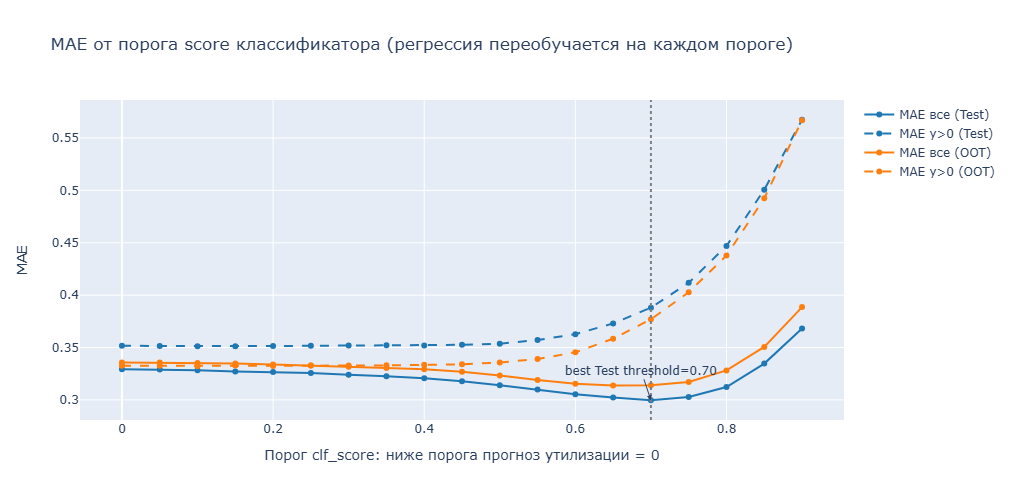

In [50]:
fig = go.Figure()
for dataset, color in [('Test', '#1f77b4'), ('OOT', '#ff7f0e')]:
    sub = mae_threshold_report[mae_threshold_report['Dataset'] == dataset]
    fig.add_trace(go.Scatter(
        x=sub['clf_threshold'],
        y=sub['MAE_all'],
        mode='lines+markers',
        name=f'MAE все ({dataset})',
        line=dict(color=color, width=2),
    ))
    fig.add_trace(go.Scatter(
        x=sub['clf_threshold'],
        y=sub['MAE_y_gt_0'],
        mode='lines+markers',
        name=f'MAE y>0 ({dataset})',
        line=dict(color=color, width=2, dash='dash'),
    ))

fig.add_vline(x=best_threshold, line_dash='dot', line_color='gray')
fig.add_annotation(
    x=best_threshold,
    y=mae_test.loc[mae_test['MAE_all'].idxmin(), 'MAE_all'],
    text=f'best Test threshold={best_threshold:.2f}',
    showarrow=True,
    arrowhead=2,
)
fig.update_layout(
    title='MAE от порога score классификатора (регрессия переобучается на каждом пороге)',
    xaxis_title='Порог clf_score: ниже порога прогноз утилизации = 0',
    yaxis_title='MAE',
    height=500,
    width=950,
)
fig.show()


## 10. Сохранение артефактов

In [ ]:
s3_secret = (await Secret.load("s3-retail")).get()

In [ ]:
ACCESS_KEY = s3_secret["access_key"]
SECRET_KEY = s3_secret["secret_key"]

In [ ]:
from minio import Minio

client = Minio(
    endpoint="10.167.8.142:9000",
    access_key=ACCESS_KEY,
    secret_key=SECRET_KEY,
    secure=False
)    

In [ ]:
def create_scored_df(df, segment_name):
    out = df[PRIMARY_KEY + [TARGET, TARGET_CLF, CLF_SCORE_COL]].copy()
    reg_pred = best_model.predict(df[best_features])
    out['reg_pred'] = reg_pred
    out['util_pred'] = hurdle_predict(df[CLF_SCORE_COL].values, reg_pred, best_threshold)
    out['segment'] = segment_name
    return out

scored_reg_df = pd.concat([
    create_scored_df(train, 'train'),
    create_scored_df(test, 'test'),
    create_scored_df(oot, 'oot'),
], ignore_index=True)

os.makedirs(PATH_MODELS_DATA, exist_ok=True)
train[PRIMARY_KEY + best_features + [TARGET, TARGET_CLF, CLF_SCORE_COL]].to_parquet(f'{PATH_MODELS_DATA}/sample_train.parquet')
test[PRIMARY_KEY + best_features + [TARGET, TARGET_CLF, CLF_SCORE_COL]].to_parquet(f'{PATH_MODELS_DATA}/sample_test.parquet')
oot[PRIMARY_KEY + best_features + [TARGET, TARGET_CLF, CLF_SCORE_COL]].to_parquet(f'{PATH_MODELS_DATA}/sample_oot.parquet')
scored_reg_df.to_parquet(f'{PATH_MODELS_DATA}/scored_df.parquet')
mae_threshold_report.to_parquet(f'{PATH_MODELS_DATA}/mae_threshold_report.parquet')
final_hurdle_report.to_parquet(f'{PATH_MODELS_DATA}/final_hurdle_report.parquet')
pd.Series({'clf_threshold': best_threshold}).to_json(f'{PATH_MODELS_DATA}/hurdle_config.json')

print(PATH_MODELS_DATA)
display(scored_reg_df.head())


In [ ]:
# === Случайная выборка из scored_df для демо (train / test / oot) ===
# Запускать после ячейки со скорингом — используется готовый scored_df

target = TARGET
pred_col = f"{target}_pred"
N_PER_SEGMENT = 5   # строк на каждый segment
SEED = 42

demo_parts = []
for seg in ["train", "test", "oot"]:
    part = scored_df.loc[scored_df["segment"] == seg]
    n = min(N_PER_SEGMENT, len(part))
    if n > 0:
        demo_parts.append(part.sample(n=n, random_state=SEED))

scored_df_demo = pd.concat(demo_parts, ignore_index=True)

if "abs_error" not in scored_df_demo.columns:
    scored_df_demo["abs_error"] = (
        scored_df_demo[target].astype(float) - scored_df_demo[pred_col]
    ).abs()

cols_demo = ["segment"] + PRIMARY_KEY + [target, pred_col, "abs_error"]
scored_df_demo_view = scored_df_demo[cols_demo].round(4)

print(
    f"Случайная выборка: {len(scored_df_demo_view)} строк "
    f"({scored_df_demo_view['segment'].value_counts().to_dict()})"
)
display(scored_df_demo_view)

demo_path = f"{REPORTS_FOLDER}/scored_df_demo_sample.xlsx"
scored_df_demo_view.to_excel(demo_path, index=False)
print(f"Сохранено: {demo_path}")

In [ ]:
psi_pred = pd.concat(all_psi, ignore_index=True)
descriptions = pd.concat(description_dfs, ignore_index=True)

## 12. Публикация модели в Model_Registry

In [ ]:
# Креды для подключения S3
s3_kwargs = (await Secret.load("s3-retail")).get()
# Пароль для работы с SB_DIRKAIM (!)
cdw_pass = (await Secret.load("pass-sb-dirkaim")).get() 


from model_repository import ModelRepository
from model_repository.dao import OracleDAO
from model_repository.storage import MinioClient

engine = oracle.create_engine_cdw(
    username="KOVALENKOVDY[SB_DIRKAIM]", password=cdw_pass
)
dao = OracleDAO(engine)
storage = MinioClient(**s3_kwargs)

# Инициализируем класс ModelRepository
repo = ModelRepository(storage=storage, dao=dao)

In [ ]:
TARGETS_CAT = [
    'supermarkets_v2_cnt_1m',
    'supermarkets_v2_sum_1m'
]


In [ ]:
import pickle
from model_repository import RegisterRequest

In [ ]:
monthYear = datetime.datetime.now().strftime('%m%y')

for target, prod in zip([TARGET], TARGETS_CAT):
    MODEL_NAME = f"{ML_TYPE}_{prod}_{monthYear}_{SUBTASK}"
    output_file = f"{PATH_MODELS_DATA}/{target}/{MODEL_NAME}.pkl"
    with open(output_file, 'wb') as file: 
        pickle.dump(results[target]['model'], file) 
    print(MODEL_NAME)
    req = RegisterRequest(
        model_name=MODEL_NAME,
        model_type="lightgbm",  # "catboost" | "lightgbm" | "sklearn" | "other"
        artifact_format="pickle",
        uri=f"retail/models/eservices-{TASK_NUM}/{SUBTASK}/{MODEL_NAME}.pkl",
        created_by=AUTHOR,
        description="Модель предсказания суммы/количества трат в MCC категории в течение 30 дней", # Описание целевой переменной
        scoring_flg=1,  # Флаг что модель на активном скоринге
        monitoring_flg=0,  # Флаг что модель на мониторинге
        is_online=0,  # Флаг онлайн модели
        model_obj=results[target]['model'],  # авто-сериализуем, авто-извлечём важности
    )
    # Регистрируем модель
    meta = repo.register(req)
    print(meta)
    # Проверка что модель зарегистрирована
    assert repo.exists(MODEL_NAME)


In [ ]:
reports_all

In [ ]:
psi_pred

In [ ]:
descriptions

In [ ]:
with pd.ExcelWriter(f"report_{MCC_CAT}.xlsx", engine="openpyxl") as writer:
    reports_all.to_excel(writer, sheet_name="Лист1", index=False)
    psi_pred.to_excel(writer, sheet_name="Лист2", index=False)
    descriptions.to_excel(writer, sheet_name="Лист3", index=False)

In [ ]:
for i in descriptions['f_name'].unique():
    print(f'{i},')

In [ ]:
for i in descriptions['proc'].unique():
    print(f'LEFT JOIN {i} t1 on a.client_did = t1.client_did ')

In [ ]:
with engine_cdw.connect() as conn:
    df_to_score = pd.read_sql(f"""select * from ema_supermarkets_mcc""", conn)

In [ ]:
df_to_score

In [ ]:
df_out = []
for target, prod in zip([TARGET], TARGETS_CAT):
    best_features = results[target]['selected']
    preds = results[target]['model'].predict(df_to_score[best_features])
    out_scores = df_to_score[['client_did', 'report_date']].copy()
    out_scores['score'] = preds
    out_scores['model_name'] = f"{ML_TYPE}_{prod}_{monthYear}_{SUBTASK}"
    df_out.append(out_scores)


## 8. EDA выборки для регрессии

Основная EDA строится после выбора `best_threshold`, потому что регрессионная модель обучается и применяется только к клиентам, которых классификатор пропускает во вторую ступень (`clf_score >= best_threshold`).

In [ ]:
# Выборка, на которой строим EDA регрессионной ступени
train_reg_eda = train_reg.copy()
test_reg_eda = test_reg.copy()
oot_reg_eda = oot_reg.copy()

train_reg_eda['segment'] = 'train'
test_reg_eda['segment'] = 'test'
oot_reg_eda['segment'] = 'oot'

regression_sample = pd.concat([train_reg_eda, test_reg_eda, oot_reg_eda], ignore_index=True)
regression_sample['year_month'] = pd.to_datetime(regression_sample[TIME_COL]).dt.to_period('M').dt.to_timestamp()

print(f"best_threshold = {best_threshold:.2f}")
display({
    'train_reg': train_reg.shape,
    'test_reg': test_reg.shape,
    'oot_reg': oot_reg.shape,
    'regression_sample': regression_sample.shape,
})
display(
    regression_sample
    .groupby('segment', observed=True)
    .agg(
        n=('client_did', 'count'),
        target_mean=(TARGET, 'mean'),
        target_median=(TARGET, 'median'),
        target_zero_share=(TARGET, lambda s: (s <= ZERO_EPS).mean()),
        clf_score_mean=(CLF_SCORE_COL, 'mean'),
    )
)

In [ ]:
# Количество клиентов по месяцам уже после фильтра классификатора
reg_counts = (
    regression_sample
    .groupby(['year_month', 'segment'], observed=True)
    .size()
    .rename('client_cnt')
    .reset_index()
)

fig_reg_counts = px.bar(
    reg_counts,
    x='year_month',
    y='client_cnt',
    color='segment',
    barmode='group',
    title='Количество клиентов в регрессионной выборке по месяцам',
)
fig_reg_counts.show()

Logger.current_logger().report_plotly(
    title='Регрессия: количество клиентов по месяцам после порога clf_score',
    series='',
    figure=fig_reg_counts,
)

In [ ]:
# Динамика таргета по месяцам на регрессионной выборке
g_reg_mean, fig_reg_mean = target_by_month(regression_sample, TIME_COL, TARGET, agg='mean')
Logger.current_logger().report_plotly(
    title='Регрессия: средний target по месяцам после порога clf_score',
    series='',
    figure=fig_reg_mean,
)

g_reg_median, fig_reg_median = target_by_month(regression_sample, TIME_COL, TARGET, agg='median')
Logger.current_logger().report_plotly(
    title='Регрессия: медианный target по месяцам после порога clf_score',
    series='',
    figure=fig_reg_median,
)

In [ ]:
# Распределение таргета на регрессионной выборке
fig_reg_hist = target_histogram(regression_sample, [TARGET], log_scale=True, figsize=(10, 5), show=True)
Logger.current_logger().report_plotly(
    title='Регрессия: распределение target после порога clf_score',
    series='',
    figure=fig_reg_hist,
)

fig_reg_box = target_boxplot(regression_sample, [TARGET], ncols=1, figsize=(8, 5), show=True)
Logger.current_logger().report_matplotlib_figure(
    title='Регрессия: boxplot target после порога clf_score',
    series='',
    figure=fig_reg_box,
    iteration=0,
)

In [ ]:
# Сводка по target на регрессионной выборке
reg_target_summary = target_summary(regression_sample, [TARGET])
display(reg_target_summary)

reg_target_summary_by_month = target_summary(regression_sample, [TARGET], by_month=True, date_col=TIME_COL)
display(reg_target_summary_by_month)

reg_target_summary_to_log = reg_target_summary_by_month.T.droplevel(0).rename_axis('metric').reset_index()
Logger.current_logger().report_table(
    title='Регрессия: статистика target после порога clf_score',
    series=' ',
    table_plot=reg_target_summary_to_log,
)

In [ ]:
res_scored = pd.concat(df_out, axis=0, ignore_index=True)

In [ ]:
res_scored.to_parquet(f'scoring/{MCC_CAT}.parquet')